In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

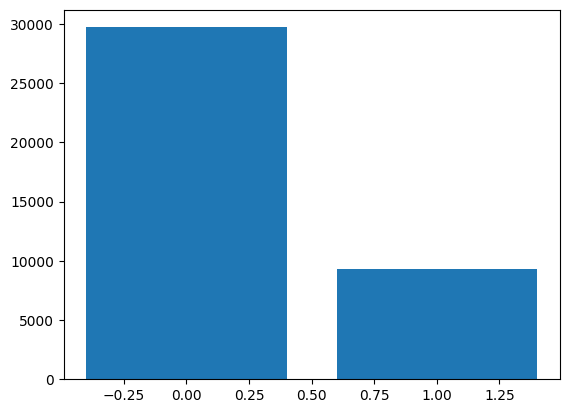

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()

train_df= pd.read_csv("train.csv")
train_df['income']= le.fit_transform(train_df['income'])

test_df= pd.read_csv("test.csv")

X= train_df.drop(columns=['sampleid', 'income'])
y= train_df['income']

X_train, X_eval, y_train, y_eval= train_test_split(X, y, train_size=0.8, stratify= y, random_state= seed)

X_test= test_df.drop(columns=['sampleid'])

plt.bar(np.unique_counts(y).values, np.unique_counts(y).counts)
plt.show()

In [91]:
# Subtask 1

answer1= []

answer1.append({
    'subtaskID': 1,
    'datapointID': 1,
    'answer': train_df[train_df['income'] == 1]['native_country'].value_counts().index[1]
})

answer1= pd.DataFrame(answer1)
answer1.head()

,subtaskID,datapointID,answer
0,1,1,Philippines


In [92]:
# Subtask 2

answer2= []

answer2.append({
    'subtaskID': 2,
    'datapointID': 2,
    'answer': train_df.groupby('occupation')['income'].mean().index[int(np.argmax(train_df.groupby('occupation')['income'].mean()))]
})

answer2= pd.DataFrame(answer2)
answer2.head()

,subtaskID,datapointID,answer
0,2,2,Exec-managerial


In [ ]:
# Subtask 3
from catboost import CatBoostClassifier

cat_cols= X.select_dtypes(include=['object']).columns.to_list()
cat_cols.pop()

for col in cat_cols:
    X_train[col] = X_train[col].astype('string').fillna('missing')
    X_eval[col] = X_eval[col].astype('string').fillna('missing')
    X_test[col] = X_test[col].astype('string').fillna('missing')

model= CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    cat_features=cat_cols,
    text_features=['profile_description'],
    early_stopping_rounds=200,
    eval_metric='TotalF1',
    random_state= seed
)

model.fit(
    X_train, y_train,
    eval_set=[(X_eval, y_eval)],
    verbose=200
)

predictions= le.inverse_transform(model.predict(X_test))

answer3= [{
    'subtaskID': 3,
    'datapointID': id_,
    'answer': pred
} for id_, pred in zip(test_df['sampleid'], predictions)]

answer3= pd.DataFrame(answer3)
answer3.head(5)

0:	learn: 0.8323776	test: 0.8333329	best: 0.8333329 (0)	total: 57.2ms	remaining: 2m 51s
200:	learn: 0.8616901	test: 0.8651762	best: 0.8651762 (197)	total: 15.3s	remaining: 3m 32s
400:	learn: 0.8692053	test: 0.8680653	best: 0.8680653 (396)	total: 29.6s	remaining: 3m 11s
600:	learn: 0.8746433	test: 0.8699441	best: 0.8705620 (486)	total: 43.3s	remaining: 2m 52s
800:	learn: 0.8788607	test: 0.8704812	best: 0.8711295 (683)	total: 57.1s	remaining: 2m 36s
1000:	learn: 0.8828569	test: 0.8718420	best: 0.8719595 (998)	total: 1m 10s	remaining: 2m 21s
1200:	learn: 0.8868297	test: 0.8717272	best: 0.8721070 (1004)	total: 1m 25s	remaining: 2m 7s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8721070427
bestIteration = 1004

Shrink model to first 1005 iterations.


,subtaskID,datapointID,answer
0,3,40343,<=50K
1,3,47681,<=50K
2,3,525,>50K
3,3,8509,<=50K
4,3,31693,>50K


In [94]:
# Subtask 4
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import HDBSCAN

cv= TfidfVectorizer()

X_test4= cv.fit_transform(test_df['profile_description'])

model= HDBSCAN()

predictions= model.fit_predict(X_test4)

answer4= [{
    'subtaskID': 4,
    'datapointID': id_,
    'answer': pred
} for id_, pred in zip(test_df['sampleid'], predictions)]

answer4= pd.DataFrame(answer4)
answer4.head(5)

,subtaskID,datapointID,answer
0,4,40343,3
1,4,47681,1
2,4,525,1
3,4,8509,4
4,4,31693,1


In [97]:
answer= pd.concat([answer1, answer2, answer3, answer4])
answer.to_csv('submission.csv', index= False)